# 04 - Social Network Analysis

**Purpose:** build the social-exposure layer used in community-attention forecasting.

The Yelp friendship graph is static, so the project treats network measures as context and exposure, not causal influence.

## Design

- Test active-reviewer thresholds: **2, 3, 5, 10, 20** local reviews.
- Keep nodes as active New Orleans reviewers.
- Keep edges as Yelp friendships between active local reviewers.
- Weight edges by local behavioral overlap: shared New Orleans businesses and reviewed-category similarity.
- Export degree, weighted degree, PageRank, weighted PageRank, component, and community features.

## Graph Design

Construct a reviewer friendship graph focused on active local reviewers. The graph is used as an exposure layer, not as proof of causal influence.


In [1]:
from pathlib import Path
import json
from collections import Counter, defaultdict
from math import log1p

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "new_orleans"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "sna"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BUSINESSES_PATH = INTERIM_DIR / "businesses.jsonl"
REVIEWS_PATH = INTERIM_DIR / "reviews.jsonl"
USERS_PATH = INTERIM_DIR / "users.jsonl"
USER_NETWORK_FEATURES_PATH = PROCESSED_DIR / "user_network_features.csv"
GRAPH_SUMMARY_PATH = PROCESSED_DIR / "social_graph_summary.json"
THRESHOLD_SENSITIVITY_PATH = PROCESSED_DIR / "active_reviewer_threshold_sensitivity.csv"

THRESHOLD_CANDIDATES = [2, 3, 5, 10, 20]
ACTIVE_REVIEW_THRESHOLD = 5

EDGE_BASE_WEIGHT = 1.0
SHARED_BUSINESS_WEIGHT = 1.0
CATEGORY_OVERLAP_WEIGHT = 1.0

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print(PROJECT_ROOT)

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp


In [2]:
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc

In [3]:
business_categories = {}
for record in iter_jsonl(BUSINESSES_PATH):
    categories = record.get("categories") or ""
    business_categories[record["business_id"]] = {
        category.strip().casefold()
        for category in categories.split(",")
        if category.strip()
    }

user_review_counts = Counter()
user_business_sets = defaultdict(set)
user_category_sets = defaultdict(set)

for record in iter_jsonl(REVIEWS_PATH):
    uid = record["user_id"]
    business_id = record["business_id"]
    user_review_counts[uid] += 1
    user_business_sets[uid].add(business_id)
    user_category_sets[uid].update(business_categories.get(business_id, set()))

all_reviewing_user_ids = set(user_review_counts)

print(f"Reviewing users: {len(all_reviewing_user_ids):,}")
print(f"Threshold candidates: {THRESHOLD_CANDIDATES}")

Reviewing users: 245,421
Threshold candidates: [2, 3, 5, 10, 20]


## Build Weighted Network

Edges represent Yelp friendship links among active New Orleans reviewers. Edge weights summarize shared local business/category context so the graph is more relevant to this city-level forecasting task.


In [4]:
def jaccard_similarity(left, right):
    if not left or not right:
        return 0.0
    return len(left & right) / len(left | right)


def local_friendship_edge(uid, fid):
    shared_business_count = len(user_business_sets[uid] & user_business_sets[fid])
    category_jaccard = jaccard_similarity(user_category_sets[uid], user_category_sets[fid])
    weight = (
        EDGE_BASE_WEIGHT
        + SHARED_BUSINESS_WEIGHT * log1p(shared_business_count)
        + CATEGORY_OVERLAP_WEIGHT * category_jaccard
    )
    return {
        "weight": weight,
        "shared_business_count": shared_business_count,
        "category_jaccard": category_jaccard,
    }


threshold_active_ids = {
    threshold: {uid for uid, count in user_review_counts.items() if count >= threshold}
    for threshold in THRESHOLD_CANDIDATES
}

threshold_graphs = {}
active_profile_counts = {}
for threshold, active_ids in threshold_active_ids.items():
    graph = nx.Graph()
    graph.add_nodes_from(active_ids)
    threshold_graphs[threshold] = graph
    active_profile_counts[threshold] = 0

matched_profiles = 0
for record in iter_jsonl(USERS_PATH):
    uid = record["user_id"]
    uid_review_count = user_review_counts.get(uid)
    if uid_review_count is None:
        continue
    matched_profiles += 1

    qualifying_thresholds = [threshold for threshold in THRESHOLD_CANDIDATES if uid_review_count >= threshold]
    if not qualifying_thresholds:
        continue
    for threshold in qualifying_thresholds:
        active_profile_counts[threshold] += 1

    friends = record.get("friends") or ""
    if friends == "None":
        continue
    for fid in friends.replace(", ", ",").split(","):
        fid = fid.strip()
        if not fid or uid >= fid:
            continue
        friend_review_count = user_review_counts.get(fid)
        if friend_review_count is None:
            continue

        max_shared_threshold = min(uid_review_count, friend_review_count)
        edge_attributes = local_friendship_edge(uid, fid)
        for threshold in THRESHOLD_CANDIDATES:
            if threshold <= max_shared_threshold:
                threshold_graphs[threshold].add_edge(uid, fid, **edge_attributes)


def graph_threshold_summary(threshold, graph):
    degree_values = [degree for _, degree in graph.degree()]
    weighted_degree_values = [degree for _, degree in graph.degree(weight="weight")]
    edge_weights = [data["weight"] for _, _, data in graph.edges(data=True)]
    shared_business_counts = [data["shared_business_count"] for _, _, data in graph.edges(data=True)]
    category_jaccards = [data["category_jaccard"] for _, _, data in graph.edges(data=True)]
    components = sorted(nx.connected_components(graph), key=len, reverse=True)
    largest_component_size = len(components[0]) if components else 0
    isolated_active_users = sum(1 for value in degree_values if value == 0)
    return {
        "active_review_threshold": threshold,
        "reviewing_users": len(all_reviewing_user_ids),
        "matched_user_profiles": matched_profiles,
        "active_users": len(threshold_active_ids[threshold]),
        "active_user_share": len(threshold_active_ids[threshold]) / len(all_reviewing_user_ids),
        "graph_nodes": graph.number_of_nodes(),
        "graph_edges": graph.number_of_edges(),
        "mean_edge_weight": pd.Series(edge_weights).mean() if edge_weights else 0,
        "mean_edge_shared_business_count": pd.Series(shared_business_counts).mean() if shared_business_counts else 0,
        "mean_edge_category_jaccard": pd.Series(category_jaccards).mean() if category_jaccards else 0,
        "connected_components": len(components),
        "largest_component_size": largest_component_size,
        "largest_component_share": largest_component_size / graph.number_of_nodes() if graph.number_of_nodes() else 0,
        "isolated_active_users": isolated_active_users,
        "isolated_active_user_share": isolated_active_users / graph.number_of_nodes() if graph.number_of_nodes() else 0,
        "median_friend_degree": pd.Series(degree_values).median() if degree_values else 0,
        "p90_friend_degree": pd.Series(degree_values).quantile(0.9) if degree_values else 0,
        "median_friend_weighted_degree": pd.Series(weighted_degree_values).median() if weighted_degree_values else 0,
        "p90_friend_weighted_degree": pd.Series(weighted_degree_values).quantile(0.9) if weighted_degree_values else 0,
    }


threshold_sensitivity = pd.DataFrame([
    graph_threshold_summary(threshold, threshold_graphs[threshold])
    for threshold in THRESHOLD_CANDIDATES
])
threshold_sensitivity.to_csv(THRESHOLD_SENSITIVITY_PATH, index=False)
threshold_sensitivity

,active_review_threshold,reviewing_users,matched_user_profiles,active_users,active_user_share,graph_nodes,graph_edges,mean_edge_weight,mean_edge_shared_business_count,mean_edge_category_jaccard,connected_components,largest_component_size,largest_component_share,isolated_active_users,isolated_active_user_share,median_friend_degree,p90_friend_degree,median_friend_weighted_degree,p90_friend_weighted_degree
0,2,245421,245419,96699,0.394013,96699,295964,1.483433,0.875177,0.215702,53481,42134,0.435723,52528,0.543211,0.0,12.0,0.000000,15.843868
1,3,245421,245419,56380,0.229728,56380,201547,1.611905,1.251266,0.241496,28625,27313,0.484445,28212,0.500390,0.0,14.0,0.000000,20.421814
2,5,245421,245419,26598,0.108377,26598,116558,1.833073,2.048551,0.267162,11508,14965,0.562636,11387,0.428115,1.0,18.0,1.320000,29.938210
3,10,245421,245419,8204,0.033428,8204,46656,2.363601,4.545289,0.294348,2548,5633,0.686616,2524,0.307655,2.0,26.0,4.263532,56.518486
4,20,245421,245419,2395,0.009759,2395,19575,3.098483,9.297573,0.323765,436,1957,0.817119,433,0.180793,5.0,38.0,13.249753,116.339816


## Graph Choice

The working threshold is **5 reviews**. It preserves a meaningful active-reviewer population and keeps the largest component above half of active nodes.

Edge weights make friendships local to the New Orleans community instead of treating every Yelp friendship as equally informative.

In [5]:
active_user_ids = threshold_active_ids[ACTIVE_REVIEW_THRESHOLD]
G = threshold_graphs[ACTIVE_REVIEW_THRESHOLD].copy()
active_profiles = active_profile_counts[ACTIVE_REVIEW_THRESHOLD]

print(f"Selected active-reviewer threshold: {ACTIVE_REVIEW_THRESHOLD}")
print(f"Matched user profiles: {matched_profiles:,}")
print(f"Active user profiles: {active_profiles:,}")
print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")

Selected active-reviewer threshold: 5
Matched user profiles: 245,419
Active user profiles: 26,598
Graph nodes: 26,598
Graph edges: 116,558


## Network Features

Compute centrality and community features that can later be aggregated over recent reviewers for each business-month.


In [6]:
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
components = sorted(nx.connected_components(G), key=len, reverse=True)
component_id_by_user = {}
component_size_by_user = {}
for cid, nodes in enumerate(components):
    for node in nodes:
        component_id_by_user[node] = cid
        component_size_by_user[node] = len(nodes)

pagerank = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6, weight=None) if G.number_of_edges() else {node: 0.0 for node in G.nodes}
weighted_pagerank = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6, weight="weight") if G.number_of_edges() else {node: 0.0 for node in G.nodes}

edge_shared_business_sum = Counter()
edge_category_jaccard_sum = Counter()
for left, right, data in G.edges(data=True):
    edge_shared_business_sum[left] += data["shared_business_count"]
    edge_shared_business_sum[right] += data["shared_business_count"]
    edge_category_jaccard_sum[left] += data["category_jaccard"]
    edge_category_jaccard_sum[right] += data["category_jaccard"]

avg_friend_shared_businesses = {
    uid: edge_shared_business_sum[uid] / degree[uid] if degree.get(uid, 0) else 0.0
    for uid in G.nodes
}
avg_friend_category_overlap = {
    uid: edge_category_jaccard_sum[uid] / degree[uid] if degree.get(uid, 0) else 0.0
    for uid in G.nodes
}

community_by_user = {node: -1 for node in G.nodes}
community_method = "not_computed"
if components and len(components[0]) >= 3:
    largest = G.subgraph(components[0]).copy()
    try:
        communities = nx.algorithms.community.louvain_communities(largest, seed=42, weight="weight")
        community_method = "weighted_louvain_largest_component"
        for community_id, nodes in enumerate(communities):
            for node in nodes:
                community_by_user[node] = community_id
    except Exception as exc:
        community_method = f"not_computed: {type(exc).__name__}: {exc}"

print(f"Connected components: {len(components):,}")
print(f"Largest component size: {len(components[0]) if components else 0:,}")
print(f"Isolated active users: {sum(1 for _, d in G.degree() if d == 0):,}")
print(f"Mean edge weight: {threshold_sensitivity.loc[threshold_sensitivity['active_review_threshold'] == ACTIVE_REVIEW_THRESHOLD, 'mean_edge_weight'].iloc[0]:.3f}")
print(f"Community method: {community_method}")

Connected components: 11,508
Largest component size: 14,965
Isolated active users: 11,387
Mean edge weight: 1.833
Community method: weighted_louvain_largest_component


In [7]:
rows = []
for uid in all_reviewing_user_ids:
    rows.append({
        "user_id": uid,
        "subset_review_count": user_review_counts[uid],
        "active_reviewer": int(uid in active_user_ids),
        "friend_degree": degree.get(uid, 0),
        "friend_weighted_degree": weighted_degree.get(uid, 0.0),
        "pagerank": pagerank.get(uid, 0.0),
        "weighted_pagerank": weighted_pagerank.get(uid, 0.0),
        "avg_friend_shared_businesses": avg_friend_shared_businesses.get(uid, 0.0),
        "avg_friend_category_overlap": avg_friend_category_overlap.get(uid, 0.0),
        "component_id": component_id_by_user.get(uid, -1),
        "component_size": component_size_by_user.get(uid, 0),
        "community_id": community_by_user.get(uid, -1),
    })

user_network_features = pd.DataFrame(rows)
user_network_features.to_csv(USER_NETWORK_FEATURES_PATH, index=False)

selected_threshold_summary = threshold_sensitivity[
    threshold_sensitivity["active_review_threshold"] == ACTIVE_REVIEW_THRESHOLD
].iloc[0].to_dict()

summary = {
    "active_review_threshold": ACTIVE_REVIEW_THRESHOLD,
    "threshold_candidates": THRESHOLD_CANDIDATES,
    "edge_weight_formula": "1 + log1p(shared_business_count) + category_jaccard",
    "reviewing_users": len(all_reviewing_user_ids),
    "matched_user_profiles": matched_profiles,
    "active_users": len(active_user_ids),
    "graph_nodes": G.number_of_nodes(),
    "graph_edges": G.number_of_edges(),
    "mean_edge_weight": selected_threshold_summary["mean_edge_weight"],
    "mean_edge_shared_business_count": selected_threshold_summary["mean_edge_shared_business_count"],
    "mean_edge_category_jaccard": selected_threshold_summary["mean_edge_category_jaccard"],
    "connected_components": len(components),
    "largest_component_size": len(components[0]) if components else 0,
    "isolated_active_users": sum(1 for _, d in G.degree() if d == 0),
    "community_method": community_method,
    "communities_assigned": len(set(v for v in community_by_user.values() if v >= 0)),
    "threshold_sensitivity_output": str(THRESHOLD_SENSITIVITY_PATH),
    "output": str(USER_NETWORK_FEATURES_PATH),
}
with GRAPH_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
    file.write("\n")
summary

{'active_review_threshold': 5,
 'threshold_candidates': [2, 3, 5, 10, 20],
 'edge_weight_formula': '1 + log1p(shared_business_count) + category_jaccard',
 'reviewing_users': 245421,
 'matched_user_profiles': 245419,
 'active_users': 26598,
 'graph_nodes': 26598,
 'graph_edges': 116558,
 'mean_edge_weight': 1.833072733525831,
 'mean_edge_shared_business_count': 2.048550936014688,
 'mean_edge_category_jaccard': 0.2671618532172656,
 'connected_components': 11508,
 'largest_component_size': 14965,
 'isolated_active_users': 11387,
 'community_method': 'weighted_louvain_largest_component',
 'communities_assigned': 63,
 'threshold_sensitivity_output': 'C:\\Users\\mehdi\\OneDrive\\Documents\\community-forecasting-yelp\\data\\processed\\new_orleans\\active_reviewer_threshold_sensitivity.csv',
 'output': 'C:\\Users\\mehdi\\OneDrive\\Documents\\community-forecasting-yelp\\data\\processed\\new_orleans\\user_network_features.csv'}

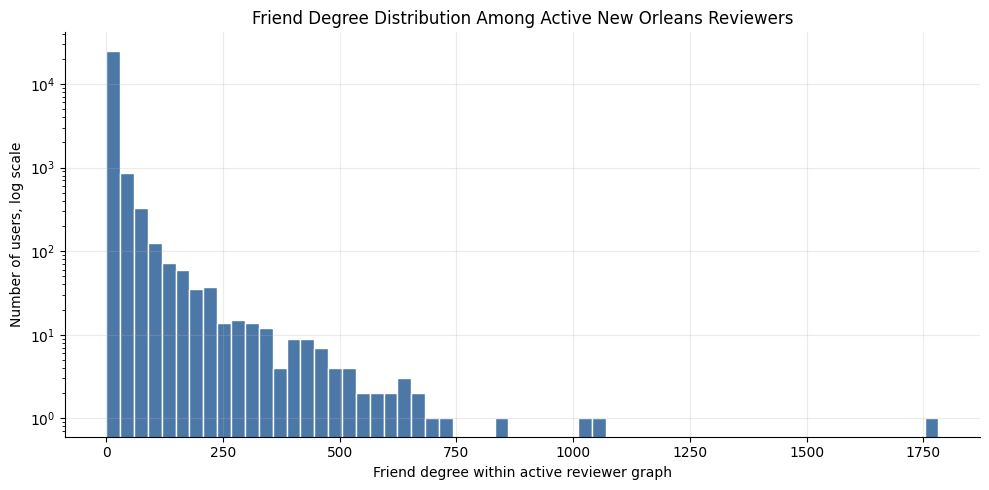

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\active_user_degree_distribution.png


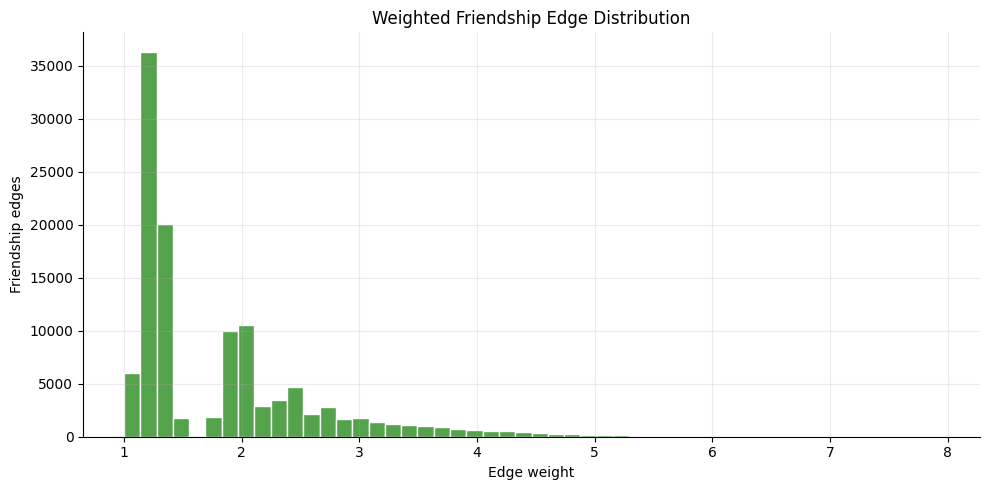

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\friendship_edge_weight_distribution.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(list(degree.values()), bins=60, color="#4C78A8", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Friend Degree Distribution Among Active New Orleans Reviewers")
ax.set_xlabel("Friend degree within active reviewer graph")
ax.set_ylabel("Number of users, log scale")
fig.tight_layout()
path = FIGURES_DIR / "active_user_degree_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

edge_weights = [data["weight"] for _, _, data in G.edges(data=True)]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(edge_weights, bins=50, color="#54A24B", edgecolor="white")
ax.set_title("Weighted Friendship Edge Distribution")
ax.set_xlabel("Edge weight")
ax.set_ylabel("Friendship edges")
fig.tight_layout()
path = FIGURES_DIR / "friendship_edge_weight_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

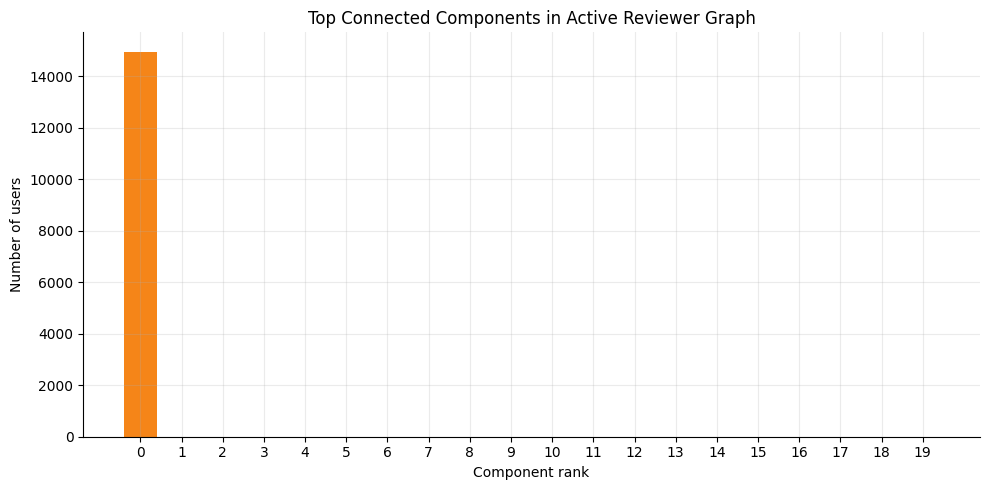

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\top_component_sizes.png


In [9]:
component_sizes = [len(c) for c in components[:20]]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(i) for i in range(len(component_sizes))], component_sizes, color="#F58518")
ax.set_title("Top Connected Components in Active Reviewer Graph")
ax.set_xlabel("Component rank")
ax.set_ylabel("Number of users")
fig.tight_layout()
path = FIGURES_DIR / "top_component_sizes.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

## SNA Takeaways

- The selected graph has **26,598 active reviewers** and **116,558 friendship edges**.
- The largest component contains **56.3%** of active reviewers.
- **42.8%** of active reviewers are isolated, so network coverage is incomplete.
- Mean edge weight is **1.83**, with **2.05 shared local businesses** and **0.27 category overlap** on average.
- These features are best interpreted as social exposure signals for later business-month aggregation.